In [17]:
### Importing the required library 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import MolStandardize
import joblib

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors,rdMolDescriptors
import utilities


In [18]:
### Installation of the basic library 
from rdkit import Chem,DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import numpy as np

In [106]:
### Now we are going to evaluate our best model over the self  experimented 
# compounds solubility with lirerature solubility 

In [3]:
import pandas as pd 
data=[['COC(=O)c1ccc(cc1)O',2.99,2.42,3.64,5.39],['COc1cc(C(=O)O)cc(OC)c1OC',2.58,3.1,2.07,1.68],['CCOC(=O)c1ccc(O)c(O)c1',2.50,2.12,3.55,2.88],
['OC(=O)c1cc(O)c(c(c1)O)O', 11.90,7.2,4.90,12.61],['O=C1OC(=O)c2c1cccc2',6.00, 12,5.01,2.57 ]

]

df_test_new = pd.DataFrame(data, columns=['SMILES', 'Sol_Literature','Sol_Experiment','VCC_Pred','Sorkun_Pred'])

In [4]:
df_test_new

,SMILES,Sol_Literature,Sol_Experiment,VCC_Pred,Sorkun_Pred
0,COC(=O)c1ccc(cc1)O,2.99,2.42,3.64,5.39
1,COc1cc(C(=O)O)cc(OC)c1OC,2.58,3.10,2.07,1.68
2,CCOC(=O)c1ccc(O)c(O)c1,2.50,2.12,3.55,2.88
3,OC(=O)c1cc(O)c(c(c1)O)O,11.90,7.20,4.90,12.61
4,O=C1OC(=O)c2c1cccc2,6.00,12.00,5.01,2.57


In [14]:
def calc_mol_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None

# Apply the function to the SMILES column
df_test_new['MW'] = df_test_new['SMILES'].apply(calc_mol_weight)



NameError: name 'Chem' is not defined

In [5]:
import utilities

In [6]:
### Generate 125 feature engineered based on the structure of the smiles ....
df125=utilities.generate123(df_test_new.SMILES)

### Fingerprint 128....

df128=utilities.fingerprint(df_test_new.SMILES,2,128)

### Generate 7 funnctional groups

df7=utilities.get_functional_groups(df_test_new.SMILES)
### Generate 38 featured engineered features 
df38=utilities.generate_features38(df_test_new.SMILES)


In [7]:
### Combining all the features  
combined_df = pd.concat([df125, df128, df7, df38], axis=1)


In [10]:
import xgboost as xgb
#xgboost_model.save_model('data/xgboost_model1.json')
loaded_model = xgb.XGBRegressor()  # or XGBRegressor for regression tasks
loaded_model.load_model('xgboost_model_298_4045.json')
pred_xgb = loaded_model.predict(combined_df)

df_test_new['LogS']=pred_xgb


In [11]:
df_test_new

,SMILES,Sol_Literature,Sol_Experiment,VCC_Pred,Sorkun_Pred,LogS
0,COC(=O)c1ccc(cc1)O,2.99,2.42,3.64,5.39,-1.826721
1,COc1cc(C(=O)O)cc(OC)c1OC,2.58,3.10,2.07,1.68,-1.853465
2,CCOC(=O)c1ccc(O)c(O)c1,2.50,2.12,3.55,2.88,-1.894378
3,OC(=O)c1cc(O)c(c(c1)O)O,11.90,7.20,4.90,12.61,-1.156953
4,O=C1OC(=O)c2c1cccc2,6.00,12.00,5.01,2.57,-1.747418


In [13]:
df_test_new['Sol_g_l']=(10**df_test_new.LogS)*df_test_new.MW

AttributeError: 'DataFrame' object has no attribute 'MW'

In [113]:
df_test_new['LogS'] = df_test_new['LogS'].round(2)
df_test_new['MW'] = df_test_new['MW'].round(2)
df_test_new['Sol_g_l'] = df_test_new['Sol_g_l'].round(2)

In [114]:
df_test_new

,SMILES,Sol_Literature,Sol_Experiment,VCC_Pred,Sorkun_Pred,MW,LogS,Sol_g_l
0,COC(=O)c1ccc(cc1)O,2.99,2.42,3.64,5.39,152.15,-1.83,2.27
1,COc1cc(C(=O)O)cc(OC)c1OC,2.58,3.10,2.07,1.68,212.20,-1.85,2.97
2,CCOC(=O)c1ccc(O)c(O)c1,2.50,2.12,3.55,2.88,182.18,-1.89,2.32
3,OC(=O)c1cc(O)c(c(c1)O)O,11.90,7.20,4.90,12.61,170.12,-1.16,11.85
4,O=C1OC(=O)c2c1cccc2,6.00,12.00,5.01,2.57,148.12,-1.75,2.65


In [114]:
## saving this result dataframe to file 
#df_test_new.to_csv('data/compare_results_new.csv')

In [115]:
### 3 Evalaution of the model with train and test data 

In [116]:
import utilities

In [117]:
df123_train=utilities.generate123(train_set.smiles_canon)
df123_test=utilities.generate123(test_set.smiles_canon)
### Generate 38 feature engineered based on the structure of the smiles ....
df38_train=utilities.generate_features38(train_set.smiles_canon)
df38_test=utilities.generate_features38(test_set.smiles_canon)
### Generate 7 funnctional groups
df7_train=utilities.get_functional_groups(train_set.smiles_canon)
df7_test=utilities.get_functional_groups(test_set.smiles_canon)
### Fingerprint 128....
df128_train=utilities.fingerprint(train_set.smiles_canon,2,128)
df128_test=utilities.fingerprint(test_set.smiles_canon,2,128)


In [118]:
y_train=train_set.copy()['LogS']
y_test=test_set.copy()['LogS']


In [119]:
### 125 and 128 fingerprint  
df253_train=pd.concat([df123_train, df128_train], axis=1)
df253_test=pd.concat([df123_test, df128_test], axis=1)

In [120]:
df260_train=pd.concat([df253_train, df7_train], axis=1)
df260_test=pd.concat([df253_test, df7_test], axis=1)

In [121]:
df298_train=pd.concat([df260_train, df38_train], axis=1)
df298_test=pd.concat([df260_test, df38_test], axis=1)

In [122]:
### Remove nan and infinity values from the dataset
df_train2 = pd.concat([df298_train, y_train], axis=1)
df_test2 = pd.concat([df298_test, y_test], axis=1)
df_train = df_train2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
df_test = df_test2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_train = df_train.iloc[:, :-1]  # All columns except the last one
y_train = df_train.iloc[:, -1] 
X_test = df_test.iloc[:, :-1]  # All columns except the last one
y_test = df_test.iloc[:, -1] 

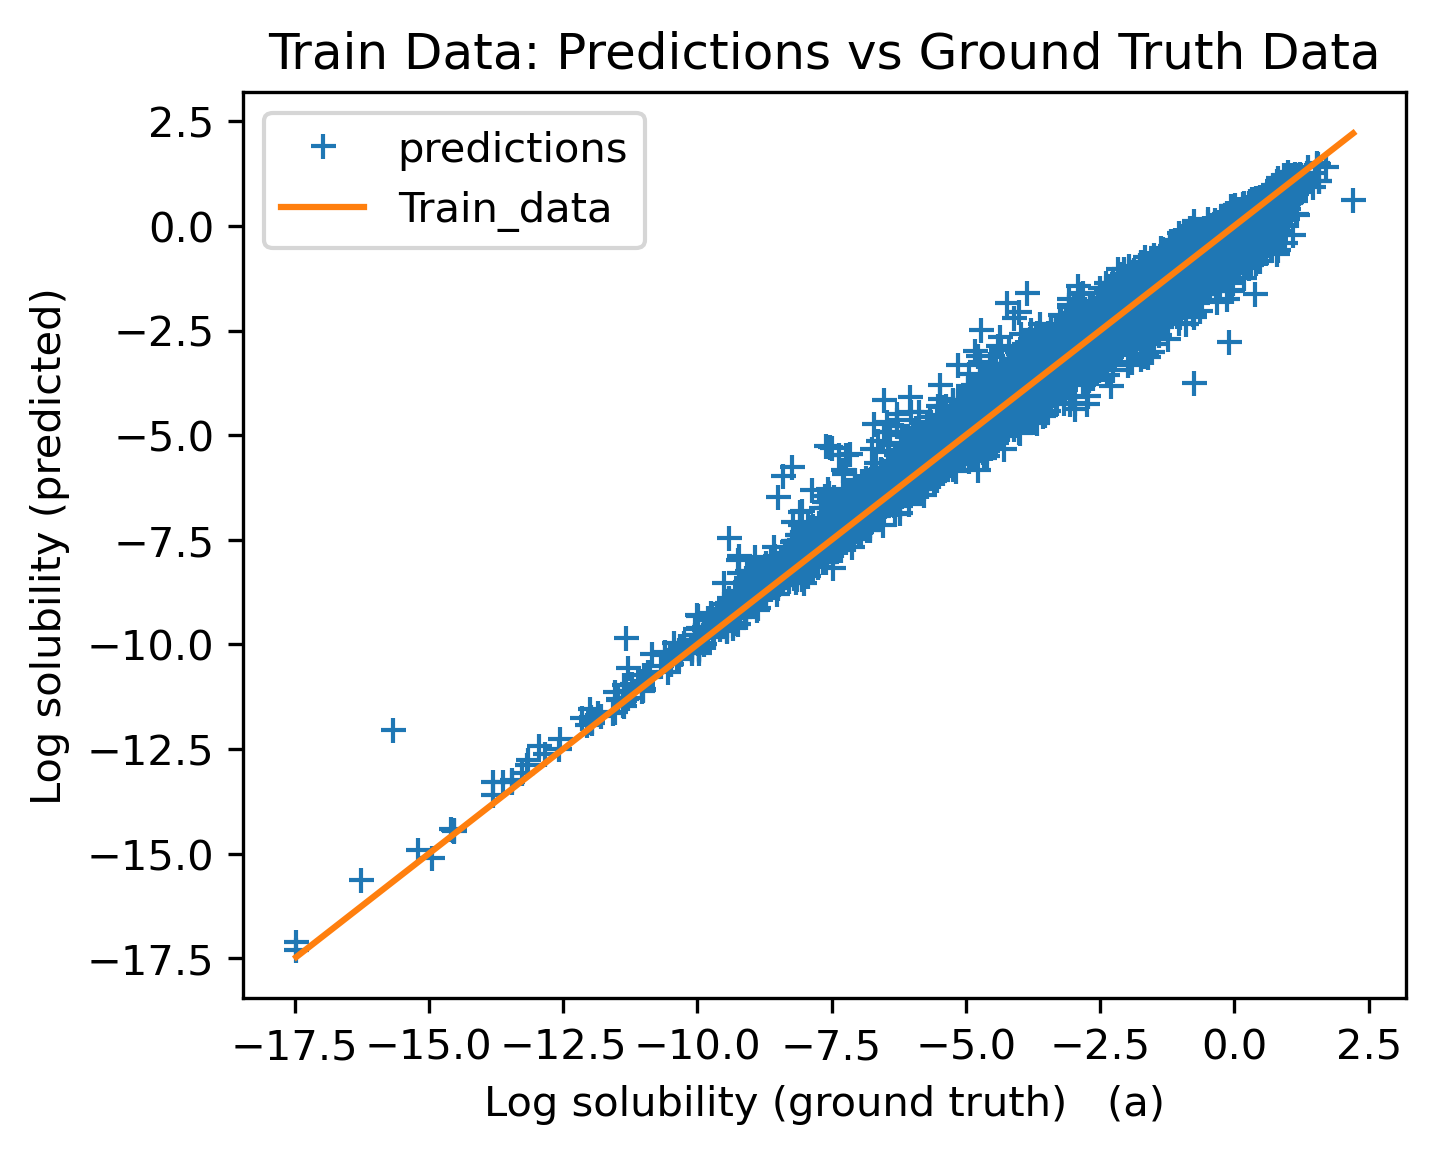

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Increase figure size and resolution
plt.figure(figsize=(5, 4), dpi=300)

# Your existing plot code
preds = loaded_model.predict(X_train)
x_y_line = np.linspace(min(y_train), max(y_train), 500)
plt.plot(y_train, preds, '+', label='predictions')
plt.plot(x_y_line, x_y_line, label='Train_data')

# Add labels, title, and legend
plt.xlabel("Log solubility (ground truth)   (a)")
plt.ylabel("Log solubility (predicted)")
plt.title("Train Data: Predictions vs Ground Truth Data")
plt.legend()

# Display the plot
plt.show()

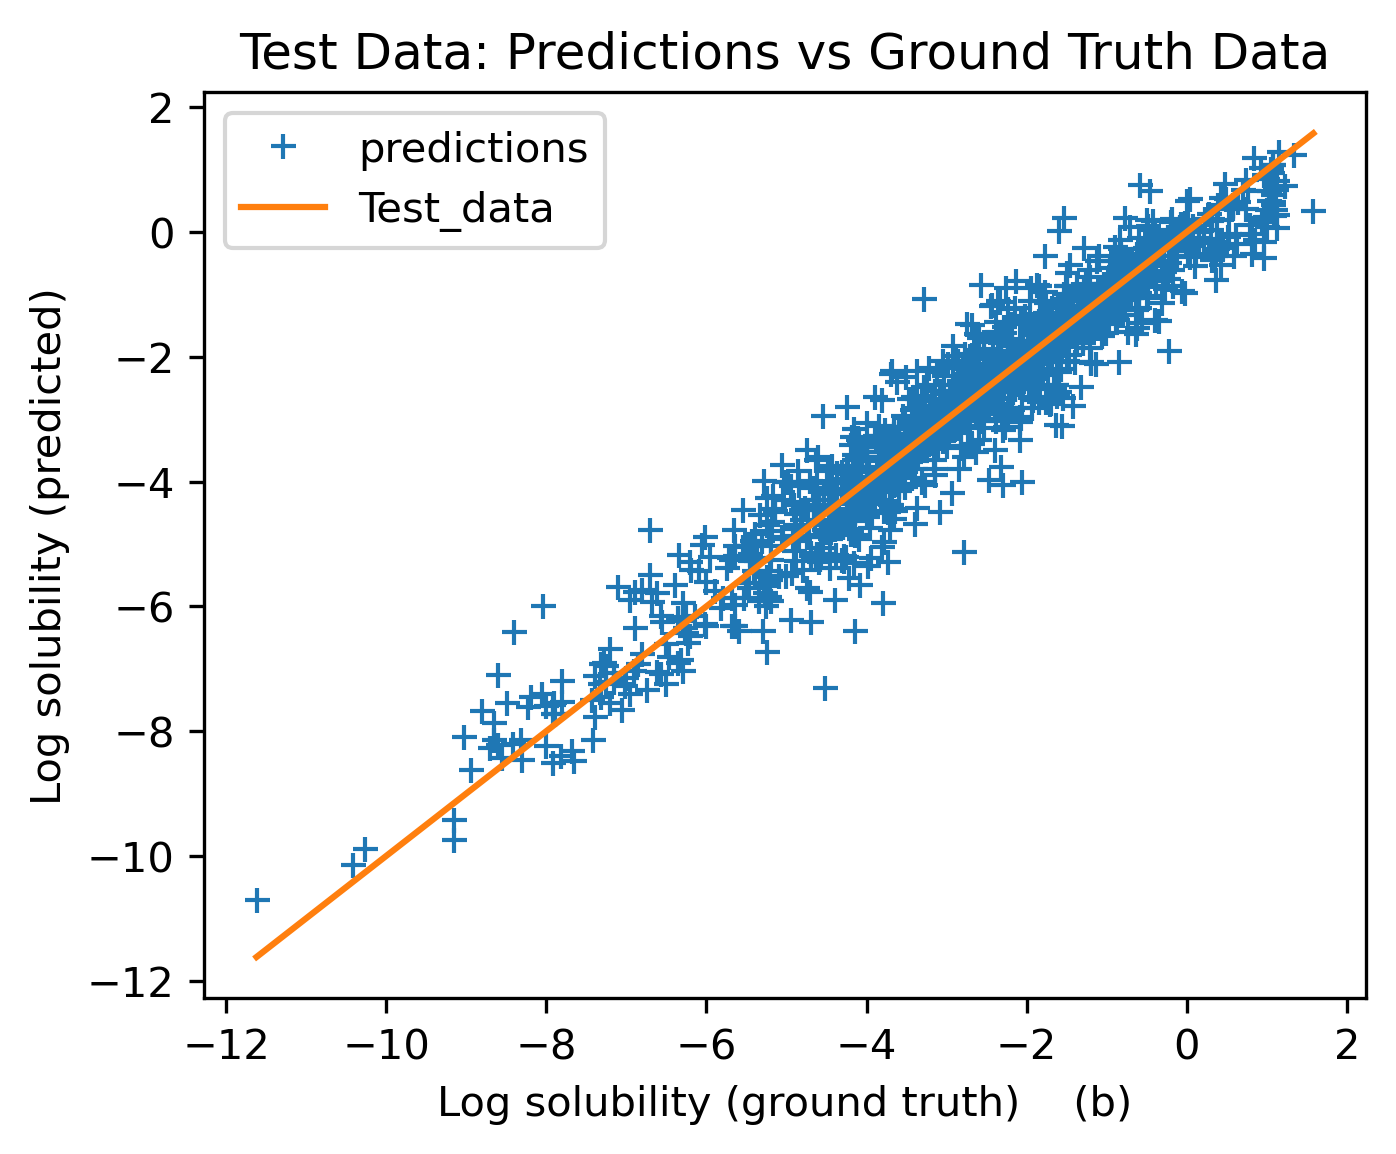

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# Increase figure size and resolution
plt.figure(figsize=(5, 4), dpi=300)

# Your existing plot code
preds = loaded_model.predict(X_test)
x_y_line = np.linspace(min(y_test), max(y_test), 500)
plt.plot(y_test, preds, '+', label='predictions')
plt.plot(x_y_line, x_y_line, label='Test_data')

# Add labels, title, and legend
plt.xlabel("Log solubility (ground truth)    (b)")
plt.ylabel("Log solubility (predicted)")
plt.title("Test Data: Predictions vs Ground Truth Data")
plt.legend()

# Display the plot
plt.show()


In [ ]:
#### END HERE ....